In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data = Path("../data/olive_oil")
epsilon = 1e-10

DATE_COLORS = {
    "20251119": "#08519c",  # blue
    "20251230": "#d62728",  # red
}

BLUE_SHADES = ["#08519c", "#3182bd", "#6baed6", "#9ecae1"]

REPS = ["Replicate_011", "Replicate_012", "Replicate_021", "Replicate_022"]

def rep_base(rep, date):
    return data / rep / f"{rep}_{date}"

def load_wr(base, mod):
    path = base / "wr" / f"{mod}_WR.csv"
    df = pd.read_csv(path)
    return df.iloc[:, 0].values, df.iloc[:, 1].values

def load_raw(folder, mod):
    files = sorted(glob.glob(str(Path(folder) / mod / "*.csv")))
    spectra, wl = [], None
    for f in files:
        df = pd.read_csv(f)
        if wl is None:
            wl = df.iloc[:, 0].values
        spectra.append(df.iloc[:, 1].values)
    return wl, (np.array(spectra) if spectra else None)

def load_norm(base, cls, mod):
    folder = base / cls
    files = sorted(glob.glob(str(folder / mod / "*.csv")))
    if not files:
        return None, None
    _, wr = load_wr(base, mod)
    spectra, wl = [], None
    for f in files:
        df = pd.read_csv(f)
        if wl is None:
            wl = df.iloc[:, 0].values
        raw = df.iloc[:, 1].values
        if mod == "FLUO":
            spectra.append(raw.copy())
        elif mod == "NIR":
            spectra.append(raw / (wr + epsilon))
        elif mod == "VIS":
            norm = raw / (wr + epsilon)
            norm[raw < 0.1 * np.max(raw)] = 0
            spectra.append(norm)
    return wl, (np.array(spectra) if spectra else None)

def plot_fused(sources, title, savepath, norm=True):
    """sources: list of {base, cls, label, color}."""
    mods    = ["NIR", "VIS", "FLUO"]
    ylabels = (["Normalized (I/I_WR)", "Normalized (I/I_WR)", "Intensity"]
               if norm else ["Intensity", "Intensity", "Intensity"])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, mod, ylabel in zip(axes, mods, ylabels):
        legend_handles = {}
        for s in sources:
            if norm:
                wl, spectra = load_norm(s["base"], s["cls"], mod)
            else:
                wl, spectra = load_raw(s["base"] / s["cls"], mod)
            if spectra is None:
                continue
            for spec in spectra:
                ax.plot(wl, spec, color=s["color"], alpha=0.4, linewidth=0.7)
            if s["label"] not in legend_handles:
                legend_handles[s["label"]] = plt.Line2D([], [], color=s["color"],
                                                        linewidth=1.5, label=s["label"])
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel(ylabel)
        ax.set_title(mod)
        ax.grid(True)
        ax.legend(handles=list(legend_handles.values()), fontsize=8)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


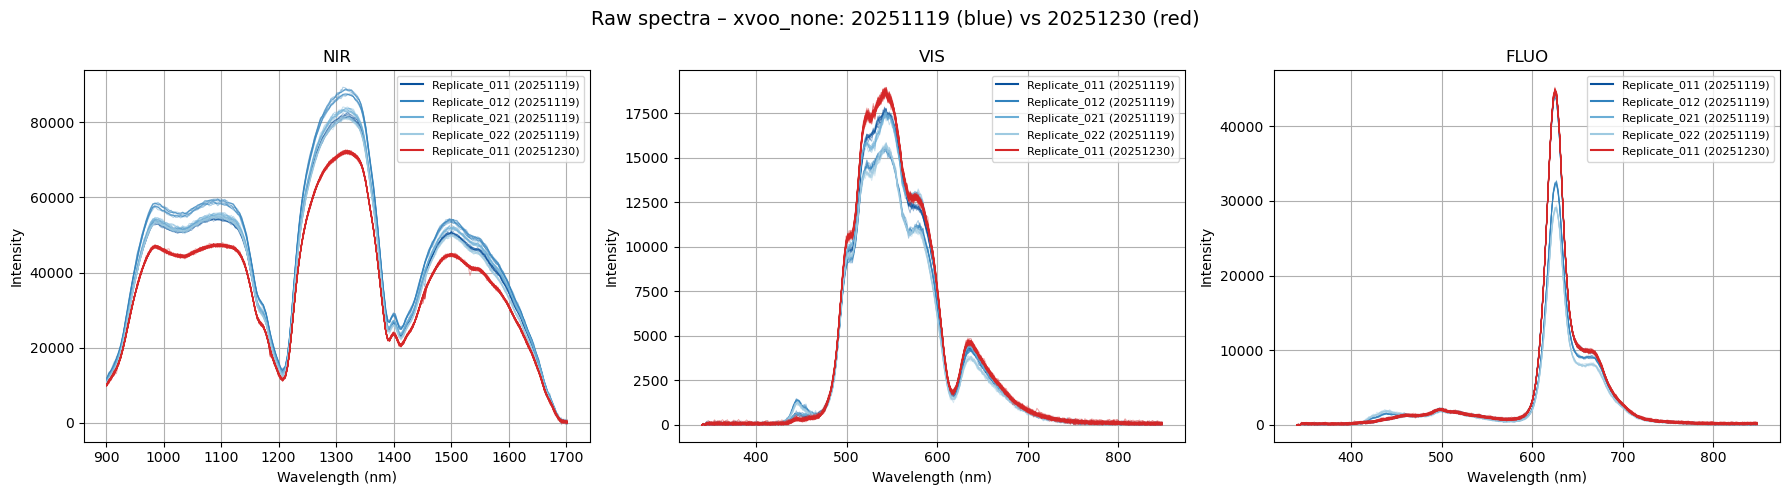

In [2]:
sources = [
    {"base": rep_base(rep, "20251119"), "cls": "xvoo_none",
     "label": f"{rep} (20251119)", "color": BLUE_SHADES[i]}
    for i, rep in enumerate(REPS)
] + [
    {"base": rep_base("Replicate_011", "20251230"), "cls": "xvoo_none",
     "label": "Replicate_011 (20251230)", "color": DATE_COLORS["20251230"]},
]

plot_fused(sources,
    title="Raw spectra – xvoo_none: 20251119 (blue) vs 20251230 (red)",
    savepath="../plots/olive_oil/fused/raw_xvoo_none_dates.png",
    norm=False)

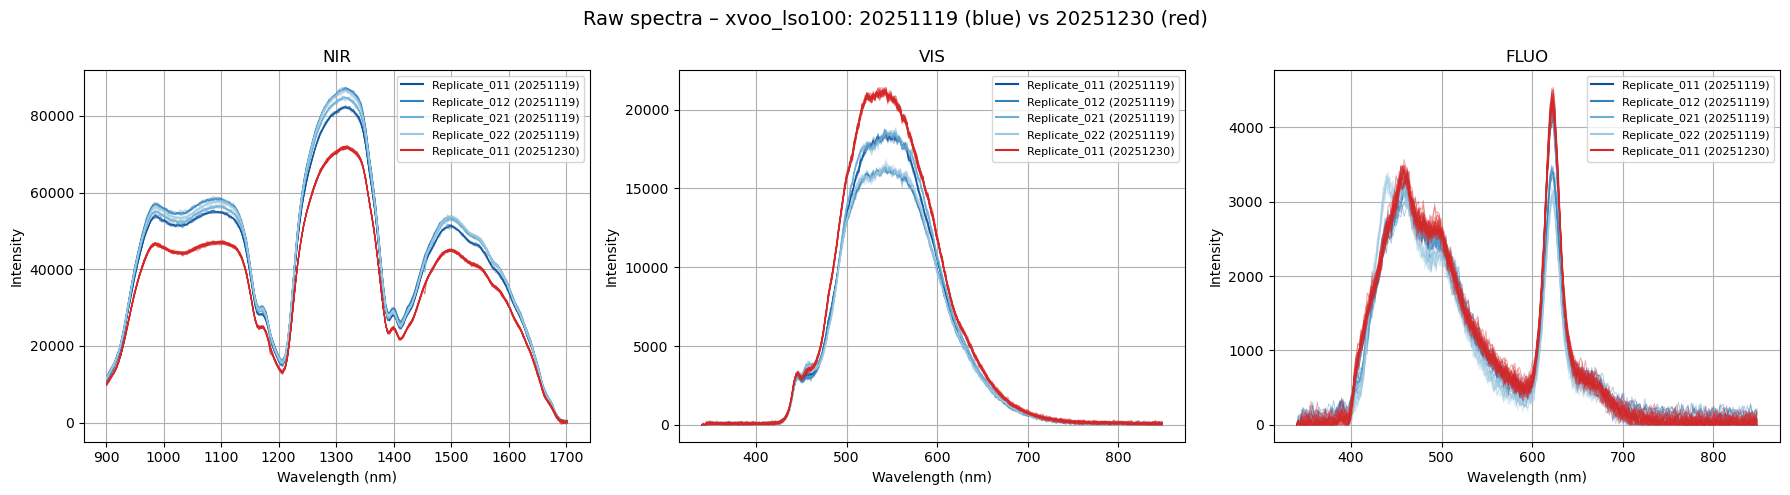

In [3]:
sources = [
    {"base": rep_base(rep, "20251119"), "cls": "xvoo_lso100",
     "label": f"{rep} (20251119)", "color": BLUE_SHADES[i]}
    for i, rep in enumerate(REPS)
] + [
    {"base": rep_base("Replicate_011", "20251230"), "cls": "xvoo_lso100",
     "label": "Replicate_011 (20251230)", "color": DATE_COLORS["20251230"]},
]

plot_fused(sources,
    title="Raw spectra – xvoo_lso100: 20251119 (blue) vs 20251230 (red)",
    savepath="../plots/olive_oil/fused/raw_xvoo_lso100_dates.png",
    norm=False)

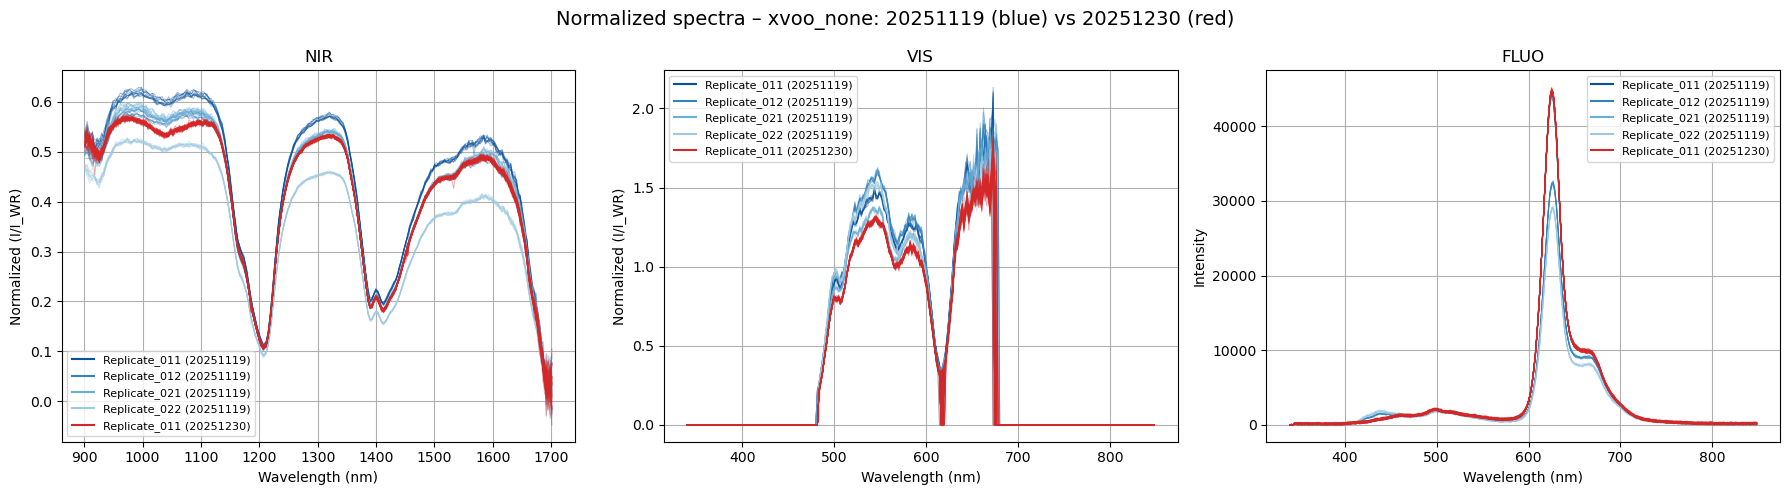

In [4]:
sources = [
    {"base": rep_base(rep, "20251119"), "cls": "xvoo_none",
     "label": f"{rep} (20251119)", "color": BLUE_SHADES[i]}
    for i, rep in enumerate(REPS)
] + [
    {"base": rep_base("Replicate_011", "20251230"), "cls": "xvoo_none",
     "label": "Replicate_011 (20251230)", "color": DATE_COLORS["20251230"]},
]

plot_fused(sources,
    title="Normalized spectra – xvoo_none: 20251119 (blue) vs 20251230 (red)",
    savepath="../plots/olive_oil/fused/norm_xvoo_none_dates.png",
    norm=True)

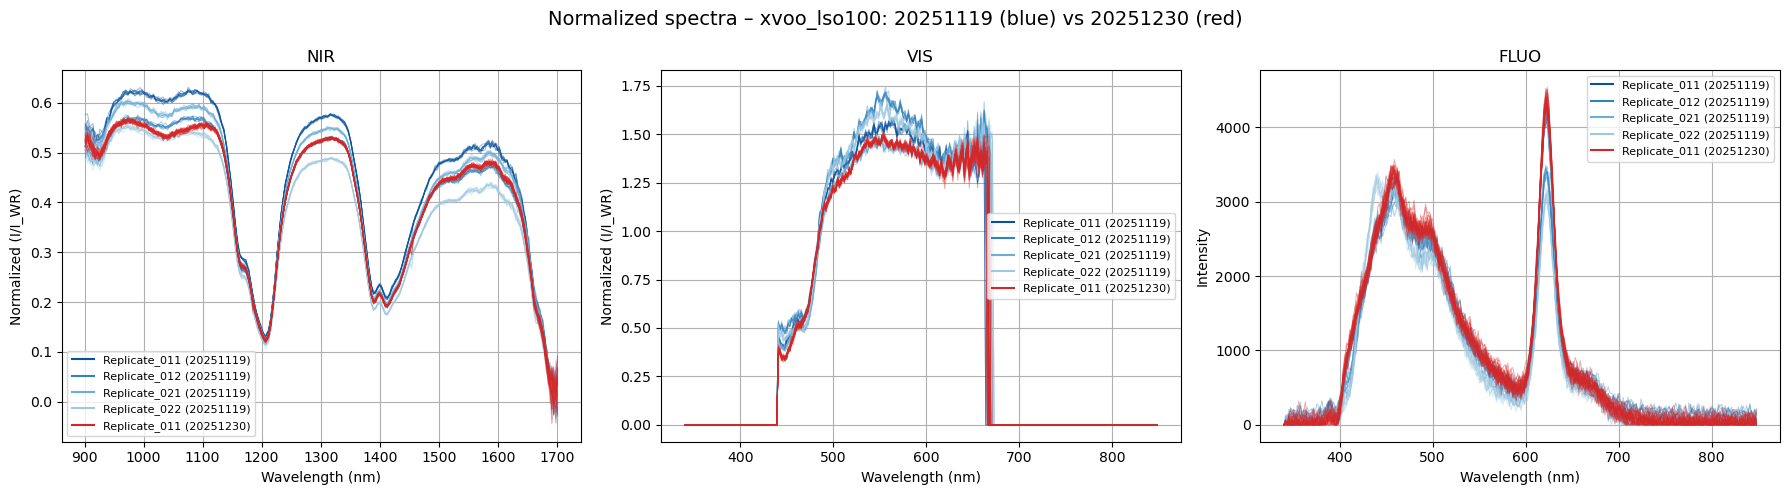

In [5]:
sources = [
    {"base": rep_base(rep, "20251119"), "cls": "xvoo_lso100",
     "label": f"{rep} (20251119)", "color": BLUE_SHADES[i]}
    for i, rep in enumerate(REPS)
] + [
    {"base": rep_base("Replicate_011", "20251230"), "cls": "xvoo_lso100",
     "label": "Replicate_011 (20251230)", "color": DATE_COLORS["20251230"]},
]

plot_fused(sources,
    title="Normalized spectra – xvoo_lso100: 20251119 (blue) vs 20251230 (red)",
    savepath="../plots/olive_oil/fused/norm_xvoo_lso100_dates.png",
    norm=True)